<a href="https://colab.research.google.com/github/islombek-cs/Computer-Vision-Labs/blob/main/Week2_CV_Lab02_Filtering_and_Edges.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name:** Islombek Abdurakhmanov  
**ID:** 221236  
**Shared Colab Link:** https://colab.research.google.com/drive/1voIfiIGDscpDd_E5v7M0GLgwGH6Ke61Z?usp=sharing



# Lab 2 — Image Processing & Filtering (Student Implementation)

**Course:** 4-COV-10-413 · Computer Vision  
**Runtime:** Google Colab  
**Policy:** You must implement core functions yourself. Using `cv2`/`scipy` is allowed **only in the comparison cells**. Copy–pasting complete solutions from the web is not allowed.

**Learning Goals**
- Implement 2D convolution from scratch.
- Build and apply Gaussian, Sobel, and Laplacian filters.
- (Optional) Design a frequency-domain filter with the FFT.
- Compare your results with library functions and reflect on differences.

> **Deliverable:** Submit this completed notebook (all cells executed) with your short reflections.


In [1]:

# ==== Setup (re-run if runtime resets) ====
!pip -q install opencv-python-headless scikit-image

import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, img_as_float
from google.colab import files

print("Versions -> numpy:", np.__version__, "| opencv:", cv2.__version__)


Versions -> numpy: 2.0.2 | opencv: 4.12.0


In [2]:

# ==== Display Helpers (do not modify) ====
import numpy as np
import matplotlib.pyplot as plt

def imshow(img, title=None, cmap=None, size=4, isOpencv=True):
    plt.figure(figsize=(size, size))
    if cmap is not None:
        plt.imshow(img, cmap=cmap)
    else:
        if img.ndim == 3 and img.shape[-1] == 3 and isOpencv:
            img = img[..., ::-1]  # BGR->RGB heuristic
        plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

def show_side_by_side(imgs, titles=None, cmaps=None, size=4, isOpencv=[]):
    n = len(imgs)
    plt.figure(figsize=(size*n, size))
    for i, im in enumerate(imgs):
        plt.subplot(1, n, i+1)
        cmap = None if cmaps is None else cmaps[i]
        if cmap is not None:
            plt.imshow(im, cmap=cmap)
        else:
            if im.ndim == 3 and im.shape[-1] == 3 and len(isOpencv)==n and isOpencv[i]:
                im = im[..., ::-1]
            plt.imshow(im)
        if titles:
            plt.title(titles[i])
        plt.axis("off")
    plt.show()



## Part 0 — Data
Use the built-in sample image for deterministic checks and feel free to upload one of your own.


RGB: (400, 600, 3) uint8 | Gray: (400, 600) uint8


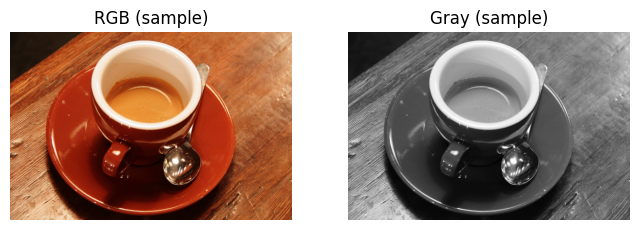

Saving mem-lion-sr-jr-dev-bug.jpg to mem-lion-sr-jr-dev-bug.jpg


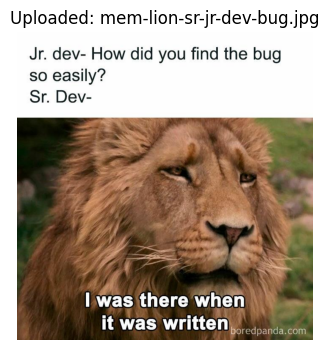

Uploaded: ['mem-lion-sr-jr-dev-bug.jpg']


In [5]:

# Built-in sample (RGB float in [0,1]), convert to uint8
img_rgb = (img_as_float(data.coffee()) * 255).astype(np.uint8)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

print("RGB:", img_rgb.shape, img_rgb.dtype, "| Gray:", img_gray.shape, img_gray.dtype)
show_side_by_side([img_rgb, img_gray], ["RGB (sample)", "Gray (sample)"], [None, "gray"], size=4)

# Optional: upload your own
uploaded = files.upload()
user_imgs = {}
for name, content in uploaded.items():
    file_bytes = np.frombuffer(content, np.uint8)
    img_cv = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)  # BGR uint8
    user_imgs[name] = img_cv
    imshow(img_cv, f"Uploaded: {name}")
print("Uploaded:", list(user_imgs.keys()))



---
## Part A — Implement 2D Convolution (from scratch)
**Task:** Implement `my_convolve2d(image, kernel)` using nested loops.  
- Grayscale input, odd kernel sizes.  
- Use zero or reflect padding (state your choice).  
- Return same image size. Clip to `[0,255]` if needed.


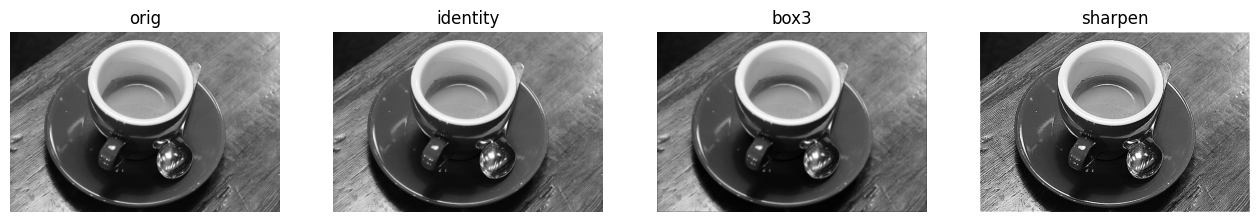

In [7]:
import numpy as np

def my_convolve2d(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:
    """
    Implement 2D convolution using nested loops (no cv2/scipy).

    - Grayscale input: shape (H, W)
    - Odd kernel size
    - Zero padding
    - Output same shape as input
    """
    # work in float for math
    img = image.astype(np.float32)
    k   = kernel.astype(np.float32)

    # flip kernel for convolution
    k = np.flipud(np.fliplr(k))

    H, W = img.shape
    kh, kw = k.shape

    pad_h, pad_w = kh // 2, kw // 2

    # zero padding around the image
    padded = np.pad(img,
                    ((pad_h, pad_h), (pad_w, pad_w)),
                    mode="constant")

    out = np.zeros_like(img, dtype=np.float32)

    # nested loops: slide kernel over image
    for i in range(H):
        for j in range(W):
            region = padded[i:i + kh, j:j + kw]   # (kh, kw)
            out[i, j] = np.sum(region * k)

    # clip to valid range and cast back
    out = np.clip(out, 0, 255)

    # keep original dtype if it was integer (usually uint8)
    if np.issubdtype(image.dtype, np.integer):
        out = out.astype(image.dtype)
    else:
        out = out.astype(np.float32)

    return out


# ---------- sanity kernels (NEEDED!) ----------

identity = np.array([[0, 0, 0],
                     [0, 1, 0],
                     [0, 0, 0]], dtype=float)

box3 = np.ones((3, 3), dtype=float) / 9.0

sharpen = np.array([[ 0, -1,  0],
                    [-1,  5, -1],
                    [ 0, -1,  0]], dtype=float)

# ---------- test (uncomment after my_convolve2d works) ----------

out_id    = my_convolve2d(img_gray, identity)
out_box   = my_convolve2d(img_gray, box3)
out_sharp = my_convolve2d(img_gray, sharpen)

show_side_by_side(
    [img_gray, out_id, out_box, out_sharp],
    ["orig", "identity", "box3", "sharpen"],
    ["gray", "gray", "gray", "gray"],
    size=4
)



### A.1 — Compare with OpenCV (validation only)


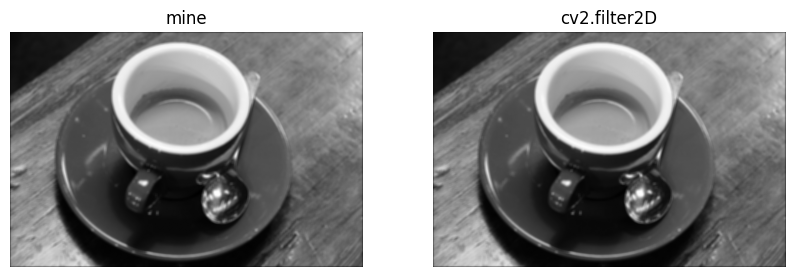

L1 diff: 0.49409166


In [8]:

# # Uncomment after implementing
out_box_mine = my_convolve2d(img_gray, np.ones((5,5))/25.0)
out_box_cv = cv2.filter2D(img_gray, ddepth=-1, kernel=np.ones((5,5), dtype=float)/25.0, borderType=cv2.BORDER_CONSTANT)
show_side_by_side([out_box_mine, out_box_cv], ["mine", "cv2.filter2D"], ["gray","gray"], size=5)
print("L1 diff:", np.mean(np.abs(out_box_mine.astype(np.float32)-out_box_cv.astype(np.float32))))



---
## Part B — Gaussian Filtering (build kernel yourself)
Implement `my_gaussian_kernel(size, sigma)` and apply it using your convolution.


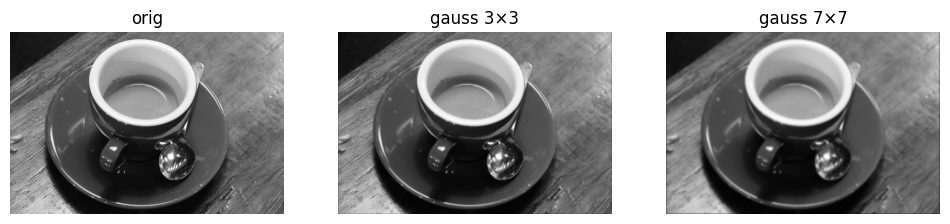

In [9]:
def my_gaussian_kernel(size: int, sigma: float) -> np.ndarray:
    """Return a normalized size×size Gaussian kernel."""
    # basic sanity check: kernel size should be odd
    if size % 2 == 0:
        raise ValueError("Gaussian kernel size must be odd")

    # coordinate grid centered at 0
    ax = np.arange(size) - size // 2
    xx, yy = np.meshgrid(ax, ax)

    # 2D Gaussian
    kernel = np.exp(-(xx**2 + yy**2) / (2.0 * sigma**2))

    # normalize so sum = 1
    kernel = kernel / kernel.sum()

    return kernel.astype(np.float32)


# --------- uncomment / add these lines after the function ---------
g3 = my_gaussian_kernel(3, 0.8)
g7 = my_gaussian_kernel(7, 1.6)

out_g3 = my_convolve2d(img_gray, g3)
out_g7 = my_convolve2d(img_gray, g7)

show_side_by_side(
    [img_gray, out_g3, out_g7],
    ["orig", "gauss 3×3", "gauss 7×7"],
    ["gray", "gray", "gray"],
    size=4,
)


### B.1 — Compare with `cv2.GaussianBlur` (validation)


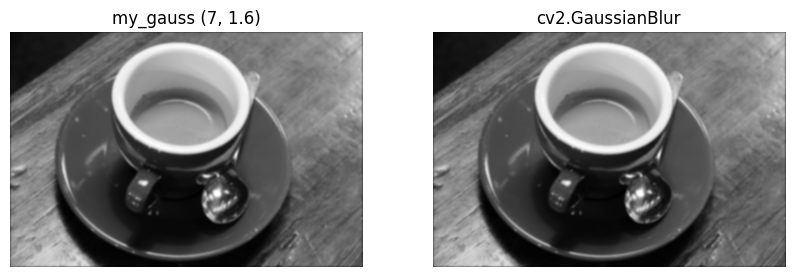

In [10]:

# # Uncomment after implementing:

out_cv = cv2.GaussianBlur(img_gray, (7, 7), 1.6, borderType=cv2.BORDER_CONSTANT)

show_side_by_side(
    [out_g7, out_cv],
    ["my_gauss (7, 1.6)", "cv2.GaussianBlur"],
    ["gray", "gray"],
    size=5,
)



---
## Part C — Sobel Edge Detection (with your convolution)
Compute Gx, Gy via Sobel kernels and the gradient magnitude image.


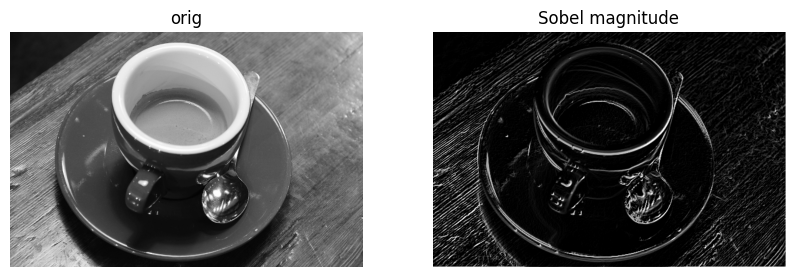

In [11]:
# Sobel edge detection using my_convolve2d

# Sobel kernels
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=float)

sobel_y = sobel_x.T

# Convolve with your function
Gx = my_convolve2d(img_gray, sobel_x)
Gy = my_convolve2d(img_gray, sobel_y)

# Gradient magnitude
G = np.sqrt(Gx.astype(np.float32)**2 + Gy.astype(np.float32)**2)

# Normalize to [0, 255] and cast to uint8
G = (255 * (G / (G.max() + 1e-8))).astype(np.uint8)

# Show result
show_side_by_side(
    [img_gray, G],
    ["orig", "Sobel magnitude"],
    ["gray", "gray"],
    size=5
)



### C.1 — Compare with OpenCV Sobel (validation)


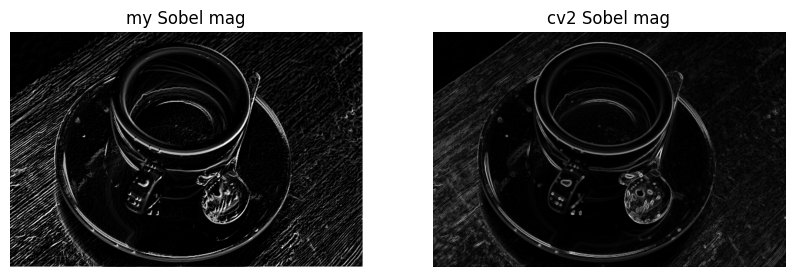

In [12]:
# Validation with OpenCV Sobel

gx_cv = cv2.Sobel(img_gray, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=3)
gy_cv = cv2.Sobel(img_gray, ddepth=cv2.CV_32F, dx=0, dy=1, ksize=3)

G_cv = np.sqrt(gx_cv**2 + gy_cv**2)
G_cv = (255 * (G_cv / (G_cv.max() + 1e-8))).astype(np.uint8)

show_side_by_side(
    [G, G_cv],
    ["my Sobel mag", "cv2 Sobel mag"],
    ["gray", "gray"],
    size=5
)



---
## Part D — Laplacian (second derivative)
Apply a 3×3 Laplacian kernel via your convolution and compare with Sobel magnitude.


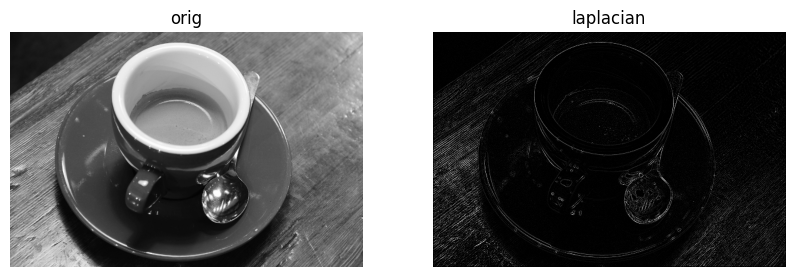

In [13]:
# Part D — Laplacian (second derivative)

# 3×3 Laplacian kernel
lap = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=float)

# Apply your convolution
out_lap = my_convolve2d(img_gray, lap).astype(np.float32)

# Normalize to [0, 255] so it looks sane
out_lap_norm = out_lap - out_lap.min()
out_lap_norm = 255 * (out_lap_norm / (out_lap_norm.max() + 1e-8))
out_lap_norm = out_lap_norm.astype(np.uint8)

# Show original vs Laplacian result
show_side_by_side(
    [img_gray, out_lap_norm],
    ["orig", "laplacian"],
    ["gray", "gray"],
    size=5
)



---
## Part E (Optional) — Frequency-Domain Filtering
Design simple low-pass / high-pass masks in the FFT domain and compare to spatial filters.


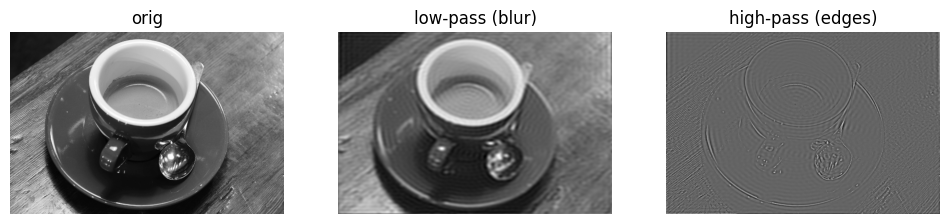

In [14]:
# Part E — Frequency-Domain Filtering (optional)

# Convert to float
img_f = img_gray.astype(np.float32)

# 1. FFT and shift zero-frequency to center
F = np.fft.fftshift(np.fft.fft2(img_f))

H, W = img_f.shape
cy, cx = H // 2, W // 2

# 2. Build circular low-pass mask
Y, X = np.ogrid[:H, :W]
dist = np.sqrt((Y - cy)**2 + (X - cx)**2)

R = min(H, W) / 8.0        # radius for low-pass (tune if you want)
mask_lp = (dist <= R).astype(np.float32)

# 3. Apply masks
F_lp = F * mask_lp              # low-pass
F_hp = F * (1.0 - mask_lp)      # high-pass

# 4. Inverse FFT to reconstruct images
img_lp = np.real(np.fft.ifft2(np.fft.ifftshift(F_lp)))
img_hp = np.real(np.fft.ifft2(np.fft.ifftshift(F_hp)))

# 5. Normalize both to [0, 255]
def norm_to_uint8(im):
    im = im - im.min()
    im = 255 * (im / (im.max() + 1e-8))
    return im.astype(np.uint8)

img_lp_u8 = norm_to_uint8(img_lp)
img_hp_u8 = norm_to_uint8(img_hp)

# 6. Show results
show_side_by_side(
    [img_gray, img_lp_u8, img_hp_u8],
    ["orig", "low-pass (blur)", "high-pass (edges)"],
    ["gray", "gray", "gray"],
    size=4
)


---
## Reflection (8–12 sentences)
Briefly answer:

**Which implementation detail was most error-prone (padding, flipping, dtype)?**  
The most error-prone part was handling padding and flipping in convolution. Using the wrong padding size or forgetting to flip the kernel caused misaligned results. Managing data types between float and uint8 also required attention to avoid overflow or rounding artifacts.  

**Effect of increasing σ in Gaussian on noise vs edges?**  
When σ increases, the Gaussian filter becomes smoother and removes more noise, but at the cost of blurring edges. A small σ preserves fine details, while a large σ smooths textures and weakens sharp boundaries.  

**Sobel vs Laplacian differences?**  
The Sobel operator detects directional gradients and provides information about edge orientation, while the Laplacian highlights all edges regardless of direction. Sobel is less sensitive to noise, whereas Laplacian reacts strongly to even small intensity changes.  

**When prefer Canny over Sobel?**  
Canny is preferred when clean, thin, and well-connected edges are required. It combines Gaussian smoothing, gradient detection, and non-maximum suppression, providing better results than simple Sobel filtering.  

**Spatial vs Frequency: one scenario where each is preferable.**  
Spatial-domain filters are best for local operations like sharpening or blurring small regions. Frequency-domain filtering is better for global control—such as designing low-pass or high-pass filters for large images or noise removal in the frequency spectrum.



---
## Grading Rubric (20 pts)
- A. Convolution implemented correctly — 6  
- B. Gaussian kernel built + applied — 4  
- C. Sobel magnitude — 4  
- D. Laplacian + comparison — 3  
- Reflection quality — 3  
- **(+2 EC)** Optional FFT filters
